# 7 距离(Distance)

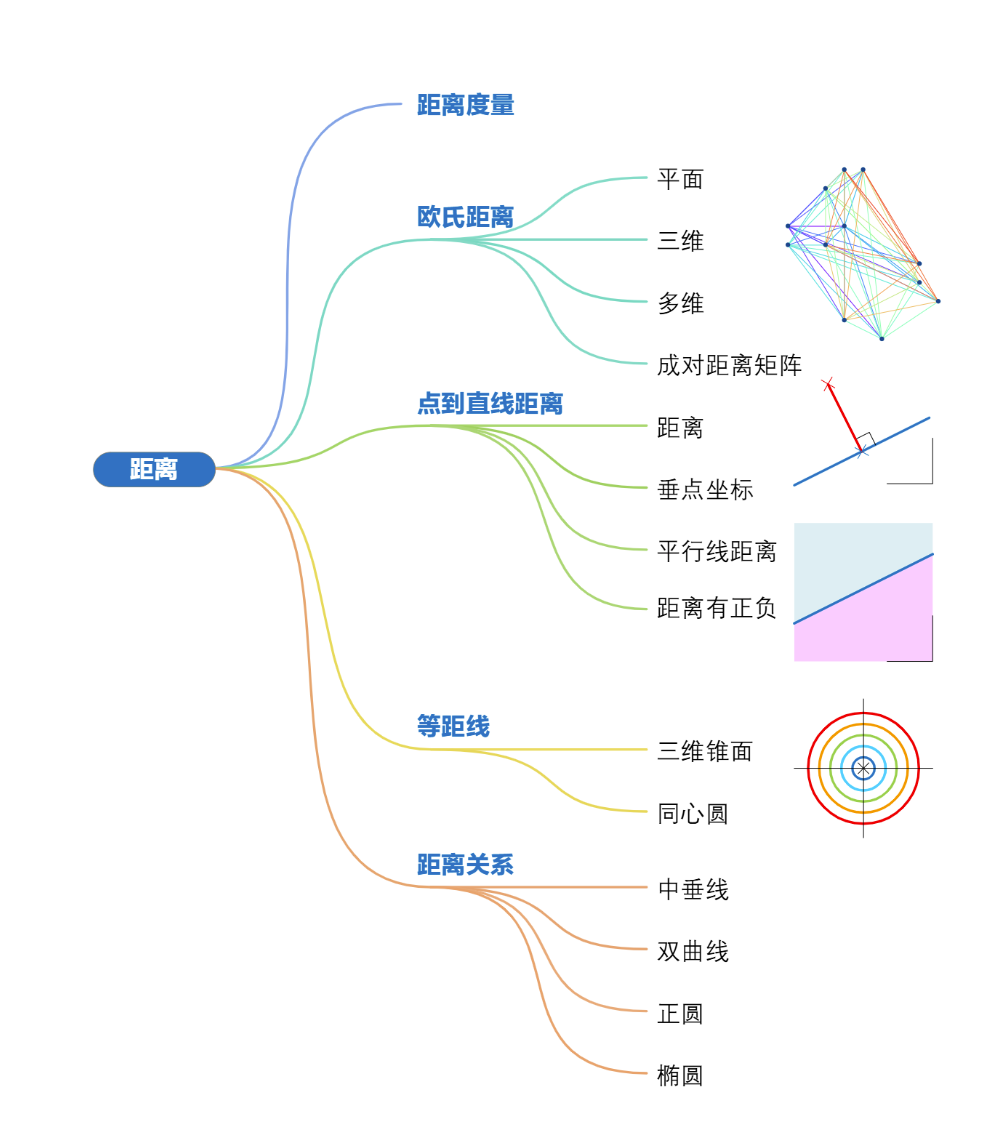

## 7.1 距离：未必是两点间的最短线段

<font color="blue">略</font>

## 7.2 欧式距离：两点间最短线段

两点之间线段长度叫做<font color="blue">欧几里得距离</font>(Euclideandistance)，或<font color="blue">欧氏距离</font>，它是最简单的距离度量。

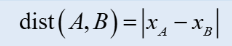

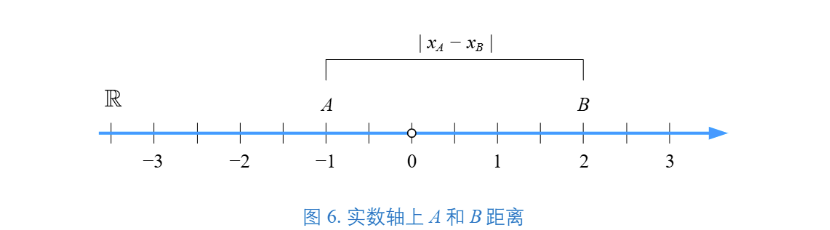

### 二维平面

平面直角坐标系中两点 $A(x_A,y_A)$ 和 $B(x_B,y_B)$ 的欧氏距离就是 $AB$ 线段的长度，可以通过如下公式求得:

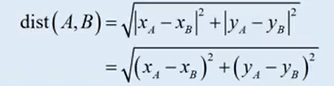

$A$ 和 $B$ 点连线的<font color="blue">中点</font>(midpoint) $M$ 的坐标为:

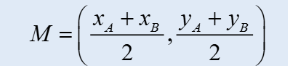

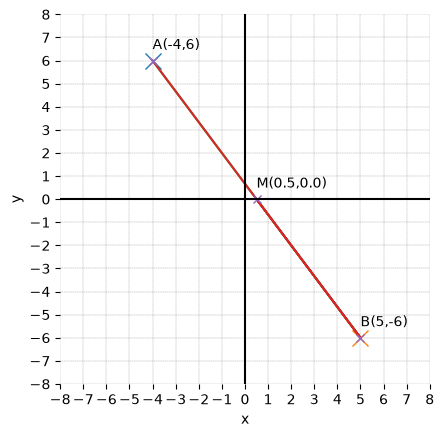

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x_A = -4
y_A = 6

x_B = 5
y_B = -6

x_M = (x_A + x_B) / 2
y_M = (y_A + y_B) / 2

fig, ax = plt.subplots()

plt.plot(x_A, y_A, "x", markersize=12)

plt.plot(x_B, y_B, "x", markersize=12)

x_points = [x_A, x_B, x_M]
y_points = [y_A, y_B, y_M]

plt.plot(x_points, y_points)
plt.plot(x_points, y_points)

labels = ["A", "B", "M"]
plt.plot(x_points, y_points, "x")

for label, i, j in zip(labels, x_points, y_points):
    plt.text(i, j + 0.5, label + f"({i},{j})")

plt.xlabel("x")
plt.ylabel("y")
plt.axhline(y=0, color="k", linestyle="-")
plt.axvline(x=0, color="k", linestyle="-")
plt.xticks(np.arange(-8, 8 + 1, step=1))
plt.yticks(np.arange(-8, 8 + 1, step=1))
plt.axis("scaled")

plt.xlim(-8, 8)
plt.ylim(-8, 8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(linestyle="--", linewidth=0.25, color=[0.5, 0.5, 0.5])

### 三维空间

三维直角坐标系中两点 $A(x_A,y_A,z_A)$和 $B(x_B,y_B,z_B)$ 的距离可以通过如下公式求得:

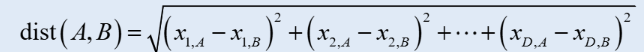

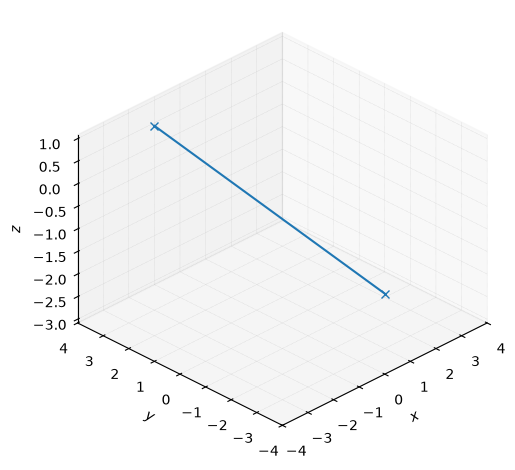

In [18]:
import numpy as np
import matplotlib.pyplot as plot

# point_A
x_A = -2
y_A = 3
z_A = 1

# point_B
x_B = 3
y_B = -1
z_B = -3

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot([x_A, x_B], [y_A, y_B], [z_A, z_B], "x", linestyle="-")

ax.set_proj_type("ortho")
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

plt.tight_layout()
ax.set_xlabel("$\it{x}$")
ax.set_ylabel("$\it{y}$")
ax.set_zlabel("$\it{z}$")
ax.view_init(azim=-135, elev=30)
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle":":"})
plt.show()

### 成对距离

### 下三角矩阵、上三角矩阵

提取方阵中主对角线及其左下方元素，它们单独构成的矩阵叫做<font color="blue">下三角矩阵</font>(lower triangular matrix) $L$。而主对角线和其右上方元素单独构成的矩阵叫做<font color="blue">上三角矩阵</font>(upper triangular matrix) $R$，其余元素为 0。

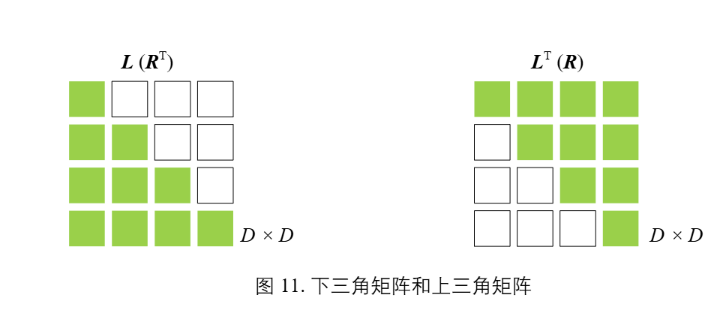

<font color="green">机器学习很多算法中常常用到亲近度(affinity)；亲近度和距离正好相反。两点距离越远，两者亲近度越低；而当它们距离越近，亲近度则越高。</font>

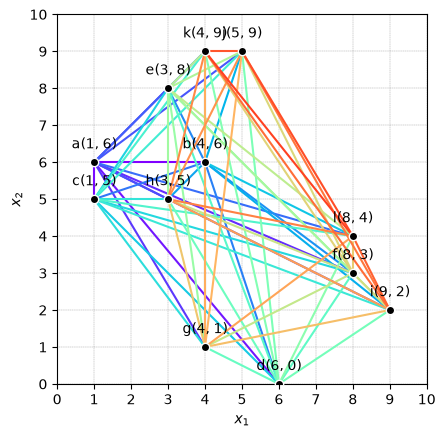

In [2]:
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np
import seaborn as sns
from matplotlib import cm

# define sample data
X = np.array([[1,6], [4, 6], [1, 5], [6, 0], [3, 8], [8, 3], [4, 1], [3, 5],
             [9, 2], [5, 9], [4, 9], [8, 4]])

# define labels
labels = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l"]

colors = plt.cm.rainbow(np.linspace(0, 1, int(len(X) * len(X) / 2)))

fig, ax = plt.subplots()

for i, d in enumerate(itertools.combinations(X, 2)):
    plt.plot([d[0][0], d[1][0]], [d[0][1], d[1][1]], color=colors[i,:])

plt.scatter(x=X[:, 0], y=X[:, 1], color='k', alpha=1.0, zorder = 1000,
            linewidth=1, edgecolor=[1,1,1])

for i, (x, y) in enumerate(zip(X[:, 0], X[:, 1])):

    # add labels to the sample data
    label = labels[i] + f"({x}, {y})"
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(0, 10), ha="center")

ax.set_xticks(np.arange(0, 11, 1))
ax.set_yticks(np.arange(0, 11, 1))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
ax.grid(linestyle="--", linewidth=0.25, color=[0.5, 0.5, 0.5])
ax.set_aspect("equal")
plt.show()

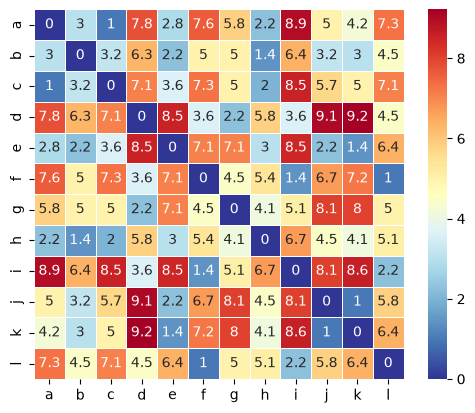

In [4]:
# 计算成对的欧氏距离
Pairwise_d = euclidean_distances(X)

fig, ax = plt.subplots()

h = sns.heatmap(Pairwise_d, cmap="RdYlBu_r", square= True, linewidth=0.5, annot=True,
               xticklabels=labels, yticklabels=labels)

plt.show()

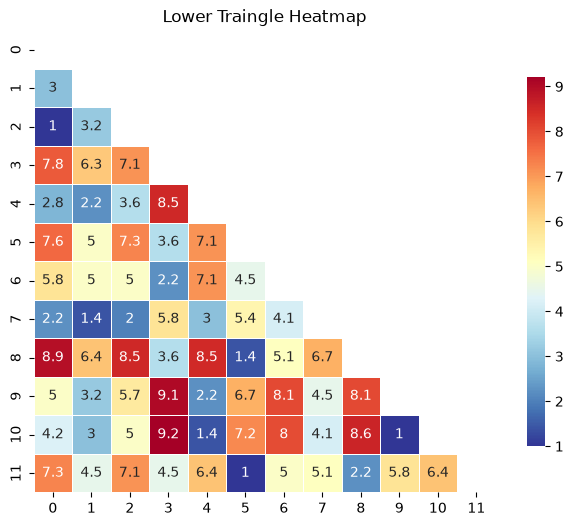

In [8]:
# 掩盖上三角
mask = np.triu(np.ones_like(Pairwise_d, dtype=bool))

# 绘制热图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Pairwise_d, mask=mask, cmap="RdYlBu_r", annot=True,
           square=True, linewidth=0.5, cbar_kws={"shrink":0.8})
plt.title("Lower Traingle Heatmap")
plt.show()


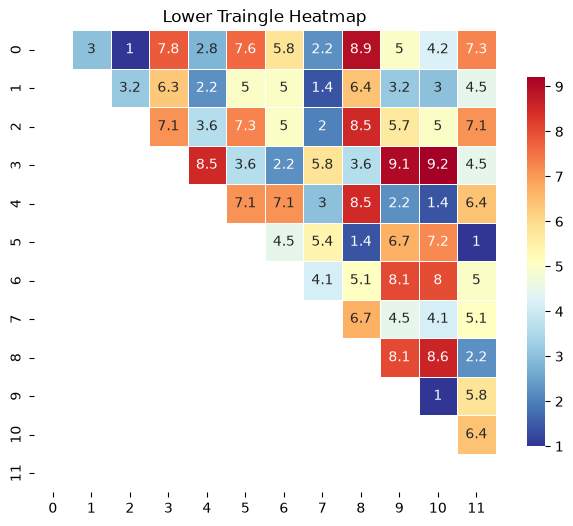

In [10]:
# 掩盖下三角
mask = np.tril(np.ones_like(Pairwise_d, dtype=bool))

# 绘制热图
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Pairwise_d, mask=mask, cmap="RdYlBu_r", annot=True,
           square=True, linewidth=0.5, cbar_kws={"shrink":0.8})
plt.title("Lower Traingle Heatmap")
plt.show()

## 7.3 点到直线的距离

给定平面上一条直线 $l:ax+by+c=0$，直线外一点 $A(x_A,y_A)$ 到该直线的距离为:

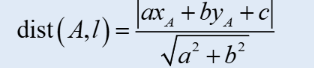

直线 $l$ 上距离 $A$ 最近点的坐标为 $H(x_H,y_H)$:

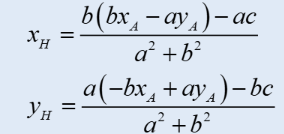

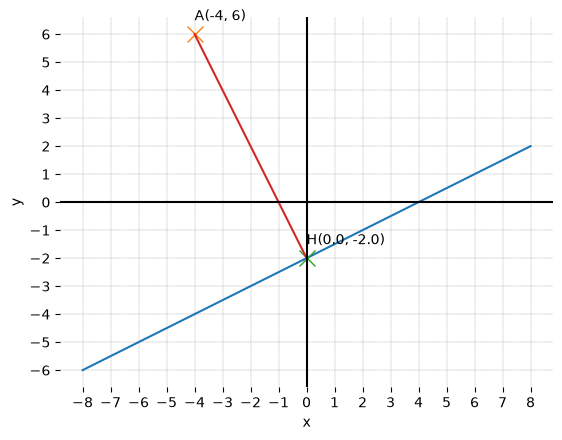

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def dist(a, b, c, x_A, y_A):
    
    dis_AH = np.abs(a * x_A + b * y_A + c) / np.sqrt(a ** 2 + b ** 2)

    x_H = (b * (b * x_A - a * y_A) - a * c) / (a ** 2 + b ** 2)
    y_H = (a * (-b * x_A + a * y_A) - b * c) / (a ** 2 + b ** 2)
    return x_H, y_H, dis_AH

x_A = -4
y_A = 6

a = 1
b = -2
c = -4

x_array = np.linspace(-8, 8, 10)
y_array = -a / b * x_array - c / b

x_H, y_H, dis_AH = dist(a, b, c, x_A, y_A)

fig, ax = plt.subplots()
plt.plot(x_array, y_array)
plt.plot(x_A, y_A, "x", markersize=12)
plt.plot(x_H, y_H, "x", markersize=12)

x_points = [x_A, x_H]
y_points = [y_A, y_H]
labels = ["A", "H"]
plt.plot(x_points, y_points, )
for label, i, j in zip(labels, x_points, y_points):
    plt.text(i, j + 0.5, label + f"({i}, {j})")

plt.xlabel("x")
plt.ylabel("y")
plt.axhline(y=0, color="k", linestyle="-")
plt.axvline(x=0, color="k", linestyle="-")
plt.xticks(np.arange(-8, 9, step=1))
plt.yticks(np.arange(-8, 9, step=1))
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.axis("scaled")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.grid(linestyle="--", linewidth=0.25, color=[0.5, 0.5, 0.5])
plt.show()

### 平行线间的距离

两条平行线的距离为：

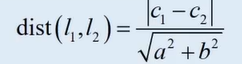

### 距离也可以有“正负”

$A$ 在 $Q$ 的左边，因此 $x_A - x_Q < 0$，也就是距离为“负”；而 $B$ 在 $Q$ 的右边，因此 $x_B -
x_Q > 0$，也就是距离为“正”。

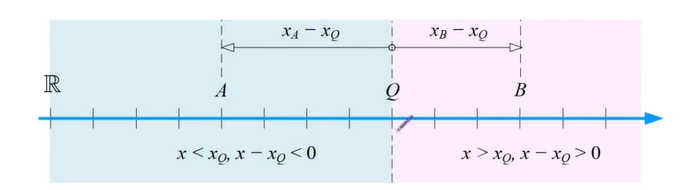

<font color="green">支持向量机(Support Vector Machine, SVM)即可以用于分类，还可以用来处理回归问题。</font>

## 7.4 等距线：换个视角看距离

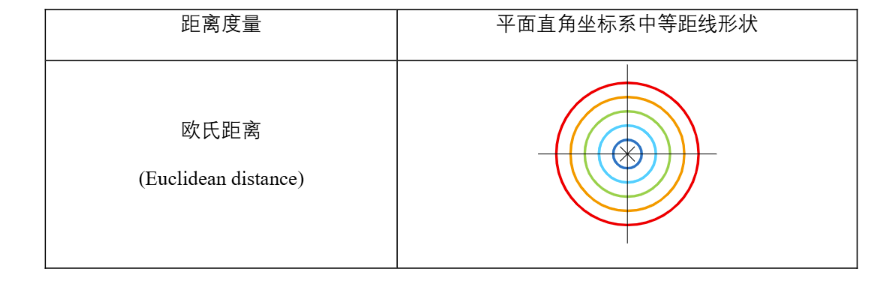
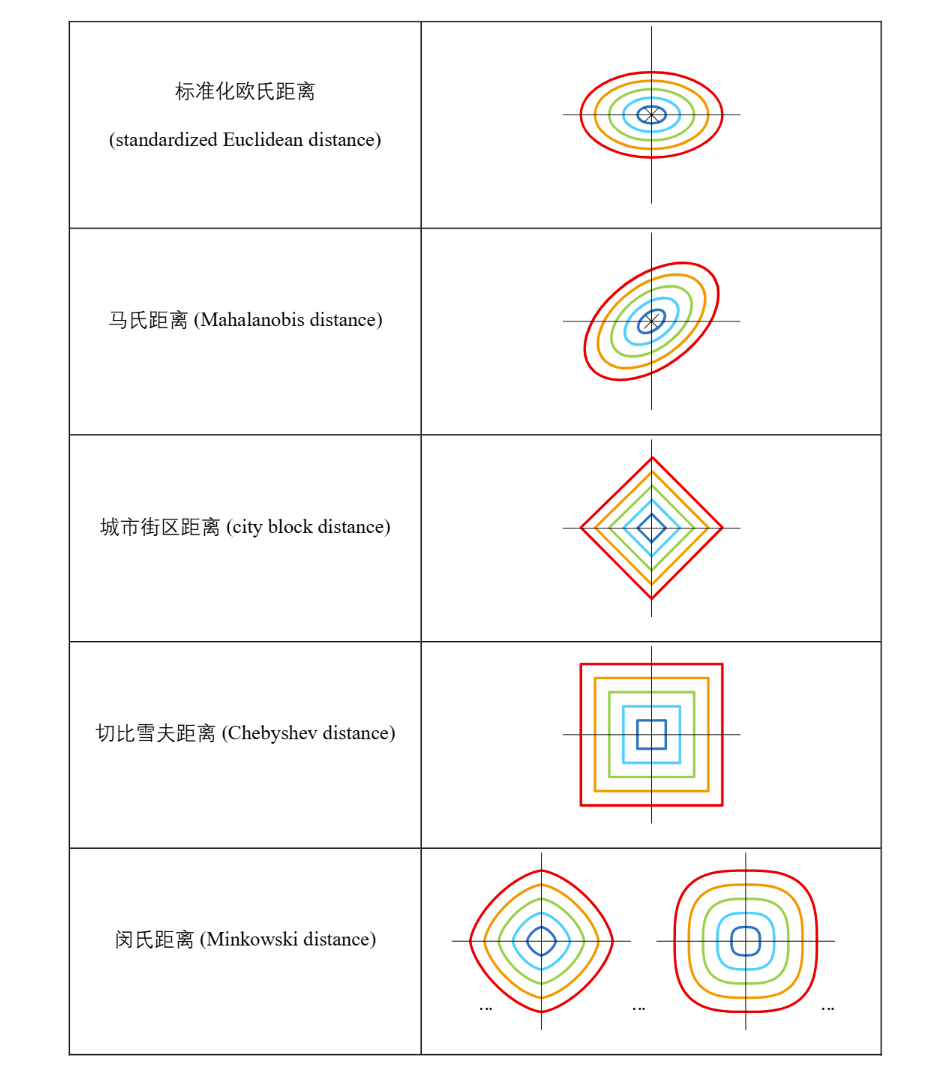

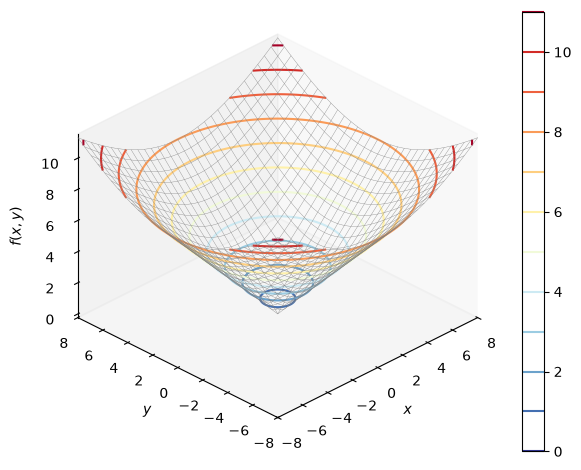

In [29]:
import numpy as np
from sympy import lambdify, sqrt
from sympy.abc import x, y
from matplotlib import pyplot as plt
from matplotlib import cm

O = [0, 0]
num = 301
x_array = np.linspace(-8, 8, num)
y_array = np.linspace(-8, 8, num)
xx, yy = np.meshgrid(x_array, y_array)

dist_OP = sqrt((x - O[0]) ** 2 + (y - O[1]) ** 2)
dist_OP_fcn = lambdify([x, y], dist_OP)   # 将符号函数转换为数值函数
dist_OP_zz = dist_OP_fcn(xx, yy)

fig = plt.figure()
ax = plt.axes(projection="3d")

ax.plot_wireframe(xx, yy, dist_OP_zz, color=[0.5, 0.5, 0.5], rstride=10, cstride=10, linewidth=0.25)
colorbar = ax.contour(xx, yy, dist_OP_zz, levels=np.arange(0, 12), cmap="RdYlBu_r")
fig.colorbar(colorbar, ax=ax)

ax.set_proj_type("ortho")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x,y)$")
plt.tight_layout()
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
ax.view_init(azim=-135, elev=30)
ax.grid(False)

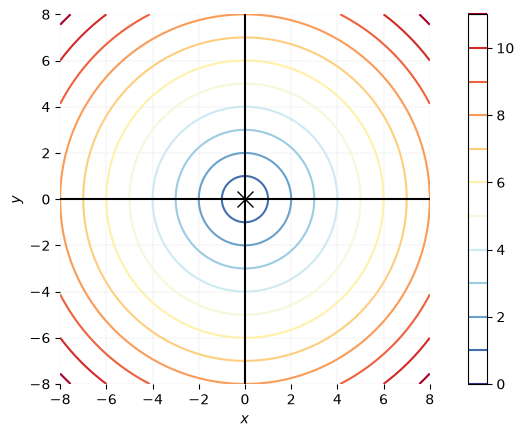

In [47]:
fig, ax = plt.subplots()

plt.plot(O[0], O[1], color="k", marker="x", markersize=12)

colorbar = ax.contour(xx, yy, dist_OP_zz, levels=np.arange(0, 12), cmap="RdYlBu_r")
fig.colorbar(colorbar, ax=ax)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.axhline(y=0, color="k", linestyle="-")
plt.axvline(x=0, color="k", linestyle="-")
plt.xticks(np.arange(-10, 10, step=2))
plt.yticks(np.arange(-10, 10, step=2))
ax.set_xlim(x_array.min(), x_array.max())
ax.set_ylim(y_array.min(), y_array.max())

plt.axis("scaled")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(linestyle="--", linewidth=0.25, color=[0.8, 0.8, 0.8])

## 7.5 距离间的量化关系

### 中垂线

$AP$ 和 $BP$ 等距，得到的是 $A$ 和 $B$ 两点的中垂线:

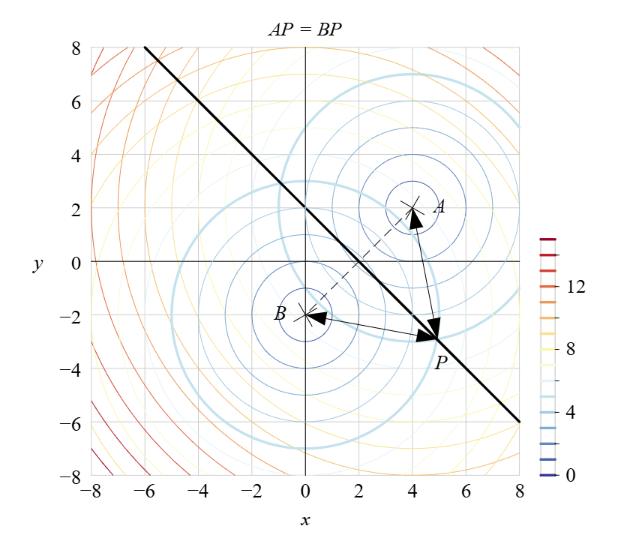

### 双曲线

$AP$ 和 $BP$ 之差为定值:
$$
AP - BP = c
$$
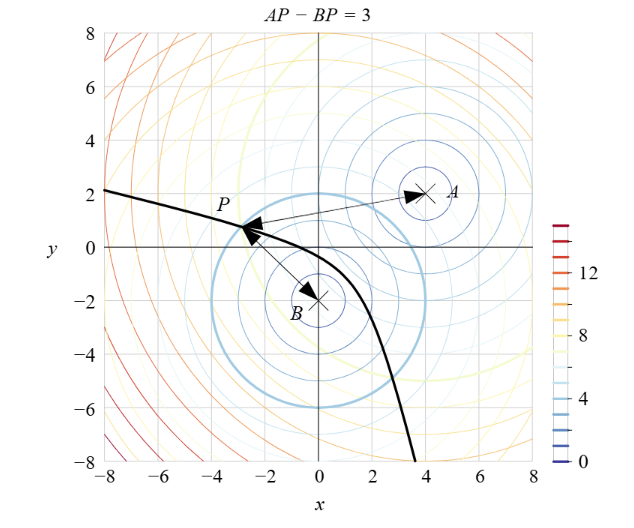

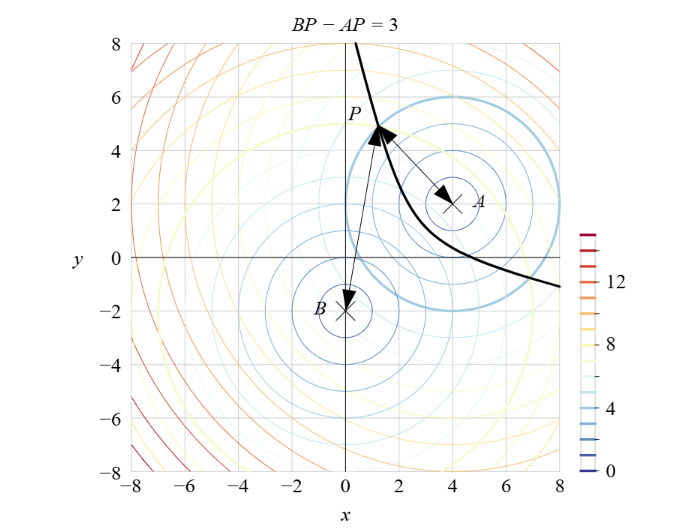

### 正圆

若线段 $AP$ 和 $BP$ 满足倍数关系:
$$
AP = c·BP
$$

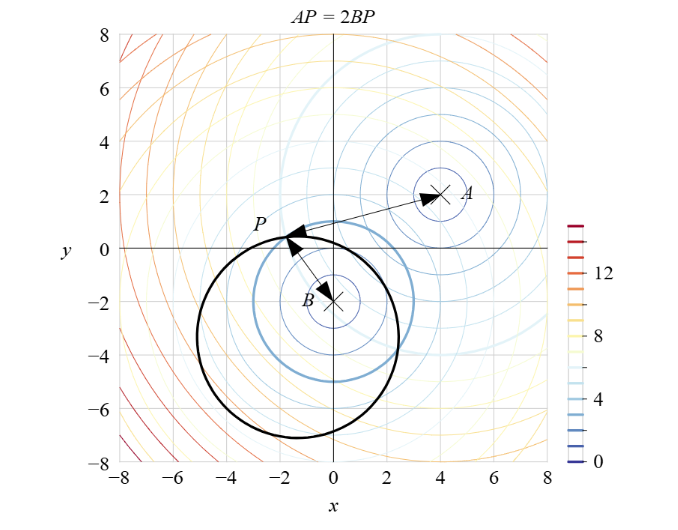

### 椭圆

$AP$ 和 $BP$ 之和为定值:
$$
AP + BP = c
$$

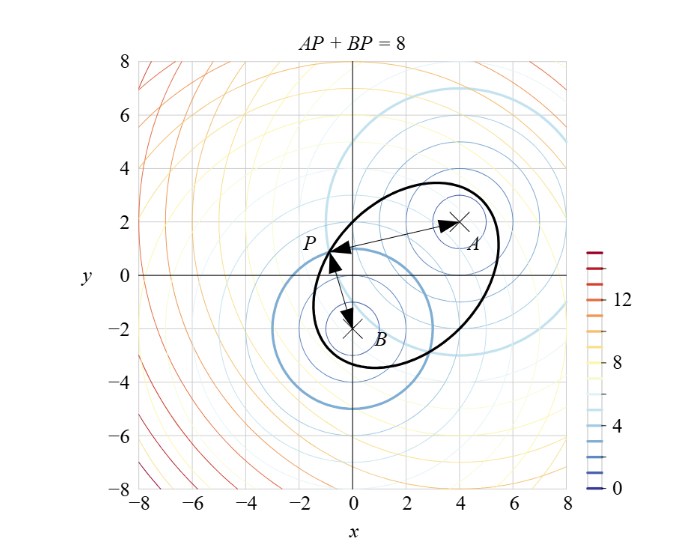

In [63]:
import numpy as np
from sympy import lambdify, sqrt
from sympy.abc import x, y
import matplotlib.pyplot as plt

def plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance):
    fig, ax = plt.subplots()
    plt.plot(A[0], A[1], color="k", marker="x", markersize=12)
    colorbar = ax.contour(xx, yy, dist_AX_zz, levels=np.arange(0, 16), cmap="RdYlBu_r")
    plt.plot(B[0], B[1], color="k", marker="x", markersize=12)
    colorbar = ax.contour(xx, yy, dist_BX_zz, levels=np.arange(0, 16), cmap="RdYlBu_r")
    ax.contour(xx, yy, distance, levels=0, colors="k")
    fig.colorbar(colorbar, ax=ax)

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    plt.axvline(x=0, color="k", linestyle="-")
    plt.axhline(y=0, color="k", linestyle="-")
    ax.set_xticks(np.arange(-10, 10, step=2))
    ax.set_yticks(np.arange(-10, 10, step=2))
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    plt.axis("scaled")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(linestyle="--", linewidth=0.25, color=[0.8, 0.8, 0.8])

In [52]:
A = [4, 2]
B = [0, -2]

In [53]:
num = 301
x_array = np.linspace(-8, 8, num)
y_array = np.linspace(-8, 8, num)
xx, yy = np.meshgrid(x_array, y_array)

In [56]:
dist_AX = sqrt((x - A[0]) ** 2 + (y - A[1]) ** 2)
dist_BX = sqrt((x - B[0]) ** 2 + (y - B[1]) ** 2)

dist_AX_fcn = lambdify([x, y], dist_AX)
dist_BX_fcn = lambdify([x, y], dist_BX)

dist_AX_zz = dist_AX_fcn(xx, yy)
dist_BX_zz = dist_BX_fcn(xx, yy)

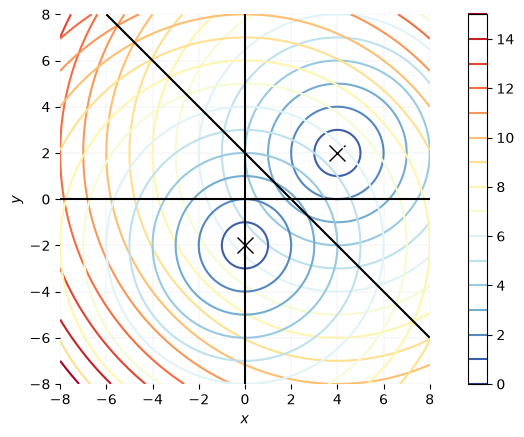

In [64]:
# AX - BX = 0
distance = dist_AX_zz - dist_BX_zz
plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance)

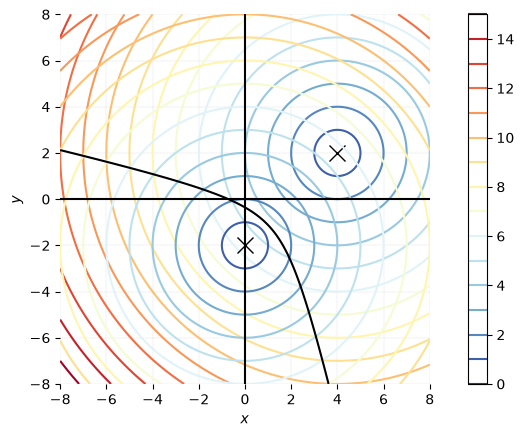

In [65]:
# AX - BX = 3
distance = dist_AX_zz - dist_BX_zz - 3
plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance)

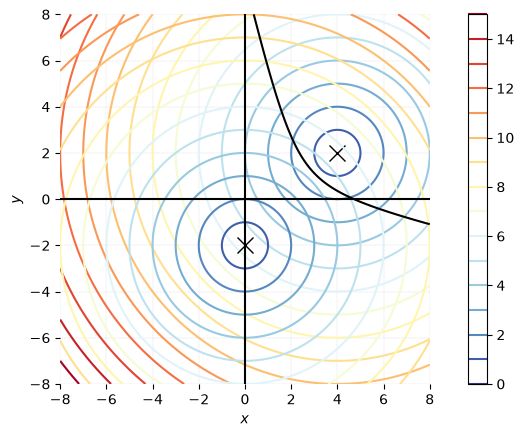

In [66]:
# AX - BX + 3 = 0
distance = dist_AX_zz - dist_BX_zz + 3  # 距离差加3
plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance)  # 绘制等高线

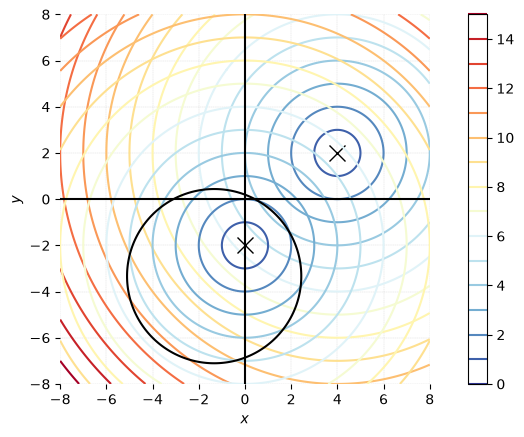

In [67]:
# AX - 2 * BX = 0
distance = dist_AX_zz - 2 * dist_BX_zz
plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance)

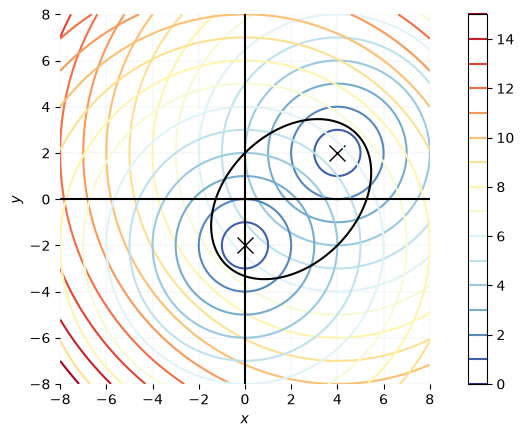

In [68]:
# BX + AX - 8 = 0
distance = dist_AX_zz + dist_BX_zz - 8
plot_fcn(A, B, dist_AX_zz, dist_BX_zz, distance)